<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [16]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-09-03 11:18:34--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  4.14MB/s    in 32s     

2026-09-03 11:19:06 (4.70 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


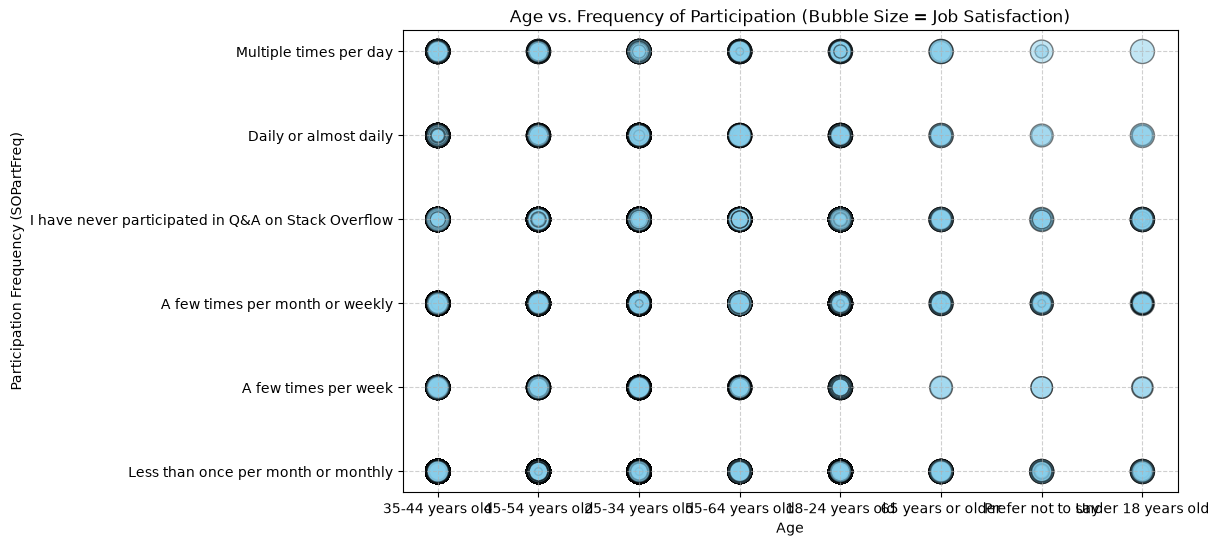

In [17]:
##Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Clean/dropna for the required columns
plot_df = df[['Age', 'SOPartFreq', 'JobSat']].dropna().copy()

# Scale the 'JobSat' values so bubble sizes are clearly visible on the plot
# Adjust multiplier (e.g., * 20 or * 50) depending on your data range
bubble_size = plot_df['JobSat'] * 30

plt.figure(figsize=(10, 6))
plt.scatter(
    x=plot_df['Age'],
    y=plot_df['SOPartFreq'],
    s=bubble_size,
    alpha=0.5,
    c='skyblue',
    edgecolors='black'
)

plt.xlabel('Age')
plt.ylabel('Participation Frequency (SOPartFreq)')
plt.title('Age vs. Frequency of Participation (Bubble Size = Job Satisfaction)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show() 

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


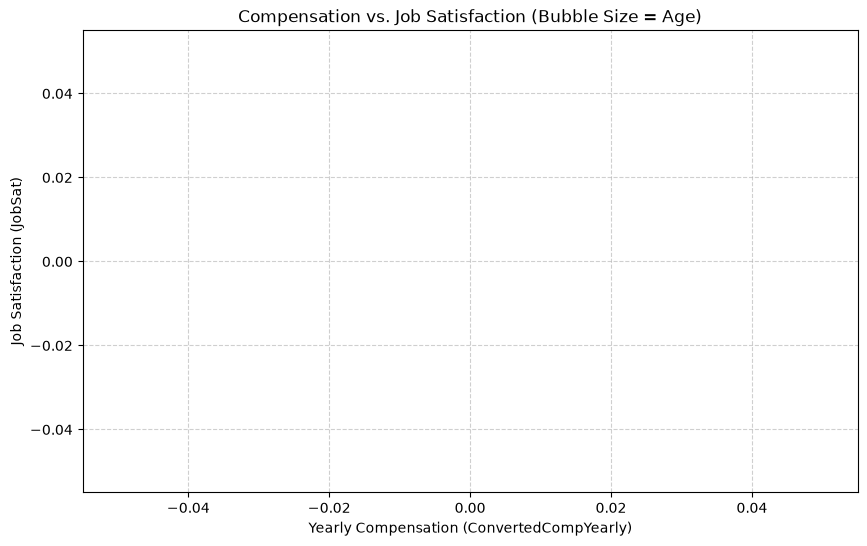

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter required columns for Task 1 Section 2
plot_df = df[['ConvertedCompYearly', 'JobSat', 'Age']].copy()

# Convert columns to numeric values
plot_df['ConvertedCompYearly'] = pd.to_numeric(plot_df['ConvertedCompYearly'], errors='coerce')
plot_df['JobSat'] = pd.to_numeric(plot_df['JobSat'], errors='coerce')
plot_df['Age'] = pd.to_numeric(plot_df['Age'], errors='coerce')

# Drop missing or non-numeric values
plot_df = plot_df.dropna()

# Filter out extreme compensation outliers so the plot displays clearly
plot_df = plot_df[(plot_df['ConvertedCompYearly'] > 0) & (plot_df['ConvertedCompYearly'] <= 300000)]

# Scale 'Age' values for bubble size
bubble_size = plot_df['Age'] * 5

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    x=plot_df['ConvertedCompYearly'],
    y=plot_df['JobSat'],
    s=bubble_size,
    alpha=0.4,
    c='coral',
    edgecolors='black'
)

plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSat)')
plt.title('Compensation vs. Job Satisfaction (Bubble Size = Age)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



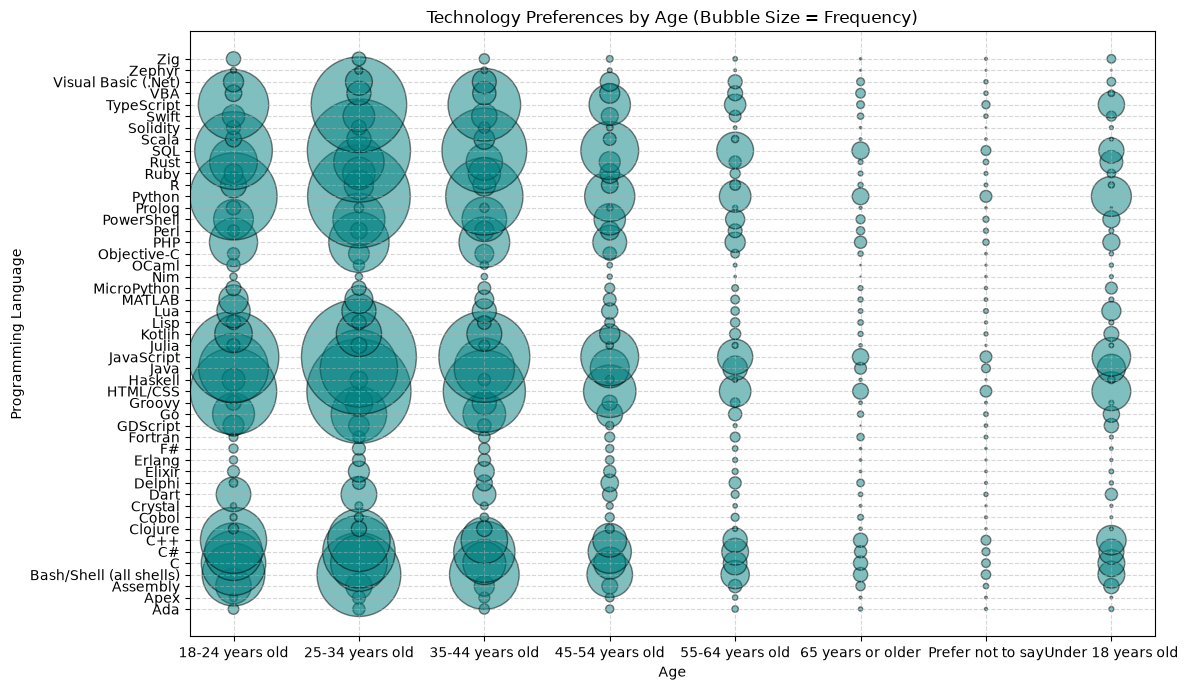

In [22]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean missing values and explode multi-value string column 'LanguageHaveWorkedWith'
lang_df = df[['Age', 'LanguageHaveWorkedWith']].dropna().copy()

# Split semicolon-separated languages into individual rows
lang_df['Language'] = lang_df['LanguageHaveWorkedWith'].str.split(';')
exploded_df = lang_df.explode('Language')

# 2. Group by Age and Language to calculate frequency (count of respondents)
grouped = (
    exploded_df.groupby(['Age', 'Language'])
    .size()
    .reset_index(name='Frequency')
)

# 3. Create the bubble plot
plt.figure(figsize=(12, 7))

# Scale frequency to determine bubble size
bubble_size = grouped['Frequency'] * 0.5  # Adjust scale factor as needed

plt.scatter(
    x=grouped['Age'],
    y=grouped['Language'],
    s=bubble_size,
    alpha=0.5,
    c='teal',
    edgecolors='black'
)

plt.xlabel('Age')
plt.ylabel('Programming Language')
plt.title('Technology Preferences by Age (Bubble Size = Frequency)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show() 

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


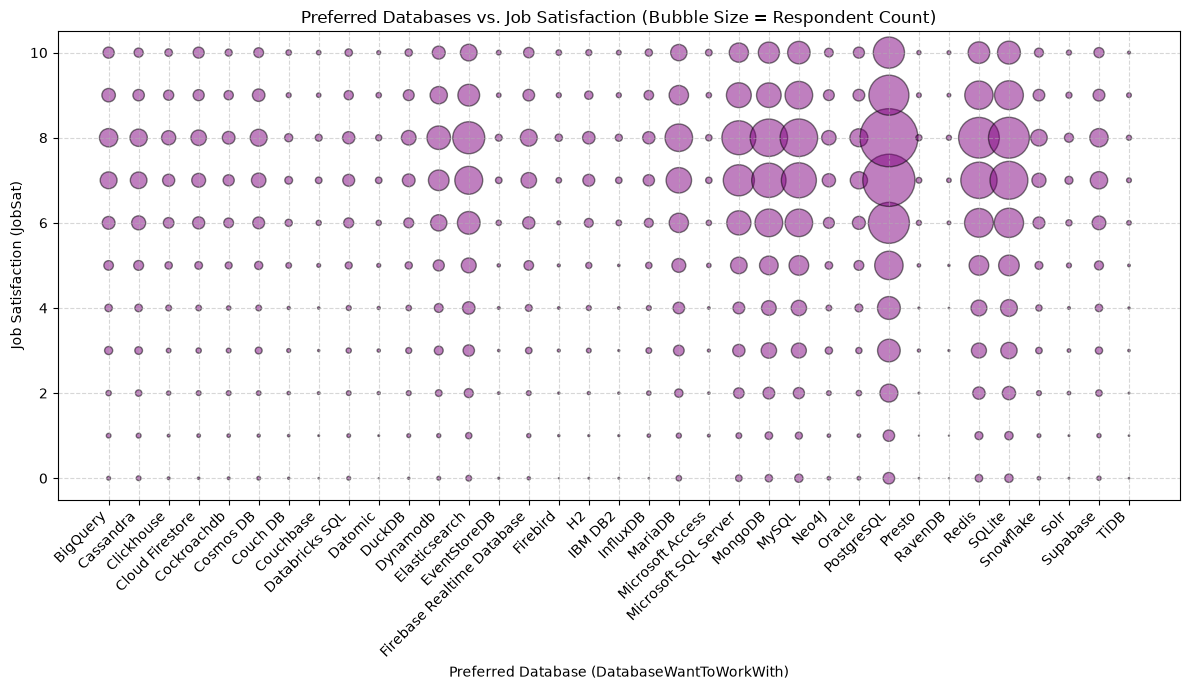

In [7]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean missing values and explode multi-value string column 'DatabaseWantToWorkWith'
db_df = df[['DatabaseWantToWorkWith', 'JobSat']].dropna().copy()

# Split semicolon-separated databases into individual rows
db_df['Database'] = db_df['DatabaseWantToWorkWith'].str.split(';')
exploded_db = db_df.explode('Database')

# 2. Group by Database and JobSat to calculate respondent counts (bubble size)
grouped_db = (
    exploded_db.groupby(['Database', 'JobSat'])
    .size()
    .reset_index(name='Count')
)

# 3. Create the bubble plot
plt.figure(figsize=(12, 7))

# Scale count for visible bubble size
bubble_size = grouped_db['Count'] * 0.5  # Adjust scaling factor if needed

plt.scatter(
    x=grouped_db['Database'],
    y=grouped_db['JobSat'],
    s=bubble_size,
    alpha=0.5,
    c='purple',
    edgecolors='black'
)

plt.xlabel('Preferred Database (DatabaseWantToWorkWith)')
plt.ylabel('Job Satisfaction (JobSat)')
plt.title('Preferred Databases vs. Job Satisfaction (Bubble Size = Respondent Count)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show() 

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


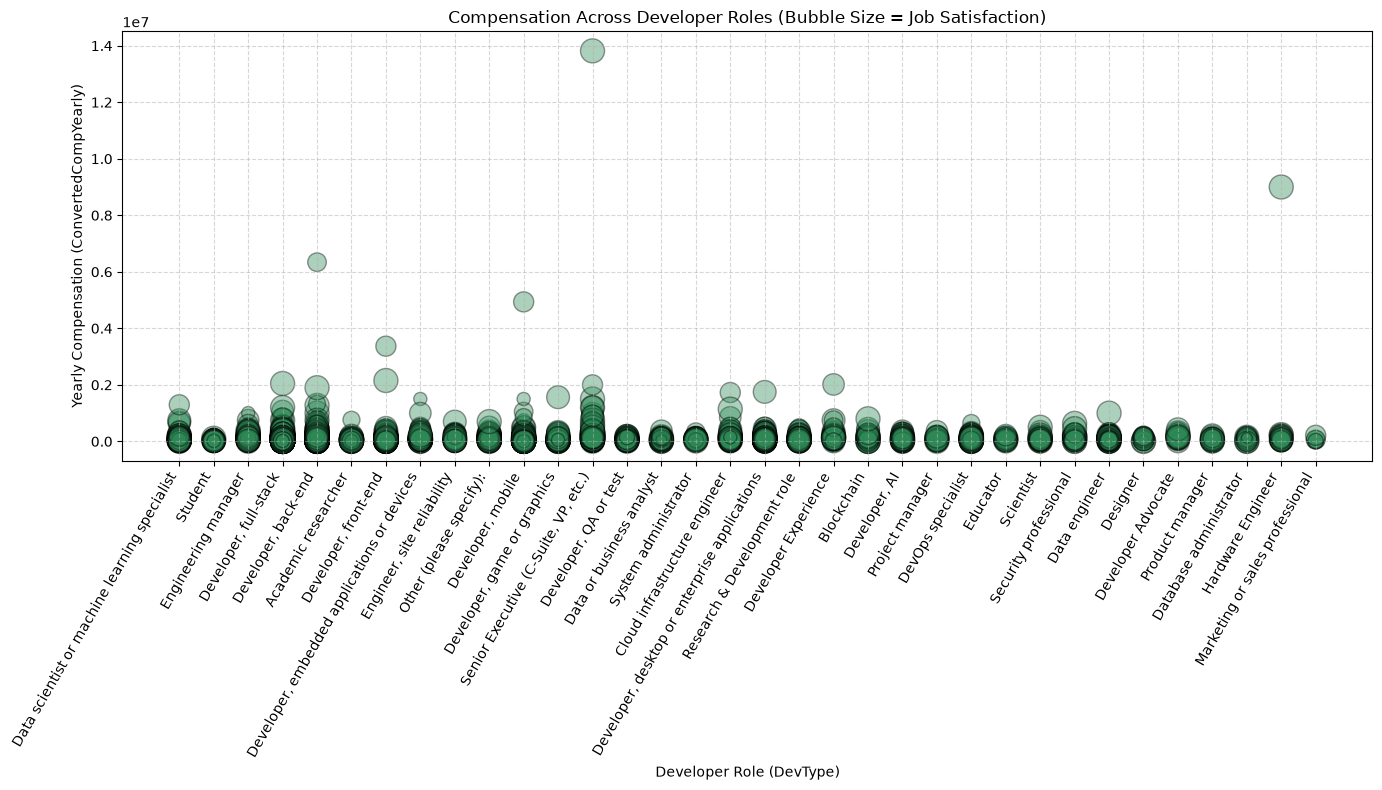

In [6]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean missing values and explode multi-value string column 'DevType'
dev_df = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna().copy()

# Split semicolon-separated developer roles if a respondent selected multiple
dev_df['Role'] = dev_df['DevType'].str.split(';')
exploded_dev = dev_df.explode('Role')

# 2. Scale JobSat for visible bubble sizes
bubble_size = exploded_dev['JobSat'] * 30

# 3. Create the bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    x=exploded_dev['Role'],
    y=exploded_dev['ConvertedCompYearly'],
    s=bubble_size,
    alpha=0.4,
    c='seagreen',
    edgecolors='black'
)

plt.xlabel('Developer Role (DevType)')
plt.ylabel('Yearly Compensation (ConvertedCompYearly)')
plt.title('Compensation Across Developer Roles (Bubble Size = Job Satisfaction)')
plt.xticks(rotation=60, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show() 

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


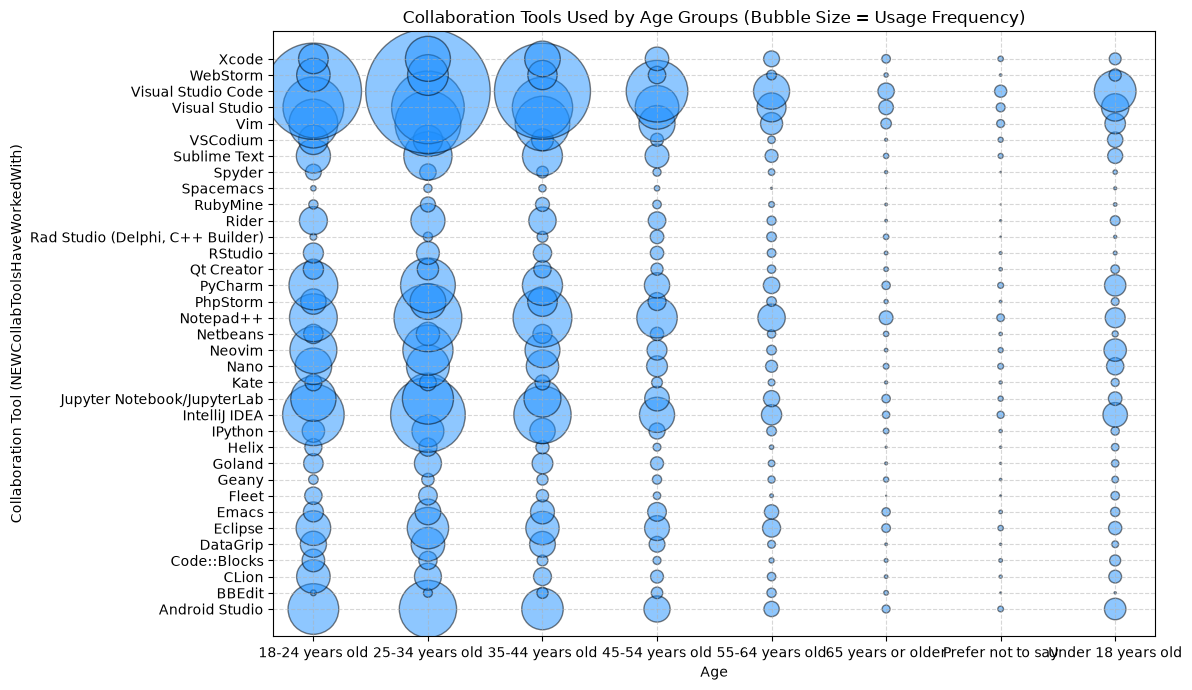

In [8]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean missing values and explode multi-value string column 'NEWCollabToolsHaveWorkedWith'
collab_df = df[['Age', 'NEWCollabToolsHaveWorkedWith']].dropna().copy()

# Split semicolon-separated collaboration tools into individual rows
collab_df['Tool'] = collab_df['NEWCollabToolsHaveWorkedWith'].str.split(';')
exploded_collab = collab_df.explode('Tool')

# 2. Group by Age and Tool to calculate frequency (count of respondents)
grouped_collab = (
    exploded_collab.groupby(['Age', 'Tool'])
    .size()
    .reset_index(name='Frequency')
)

# 3. Create the bubble plot
plt.figure(figsize=(12, 7))

# Scale frequency for visible bubble size
bubble_size = grouped_collab['Frequency'] * 0.5  # Adjust multiplier if needed

plt.scatter(
    x=grouped_collab['Age'],
    y=grouped_collab['Tool'],
    s=bubble_size,
    alpha=0.5,
    c='dodgerblue',
    edgecolors='black'
)

plt.xlabel('Age')
plt.ylabel('Collaboration Tool (NEWCollabToolsHaveWorkedWith)')
plt.title('Collaboration Tools Used by Age Groups (Bubble Size = Usage Frequency)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



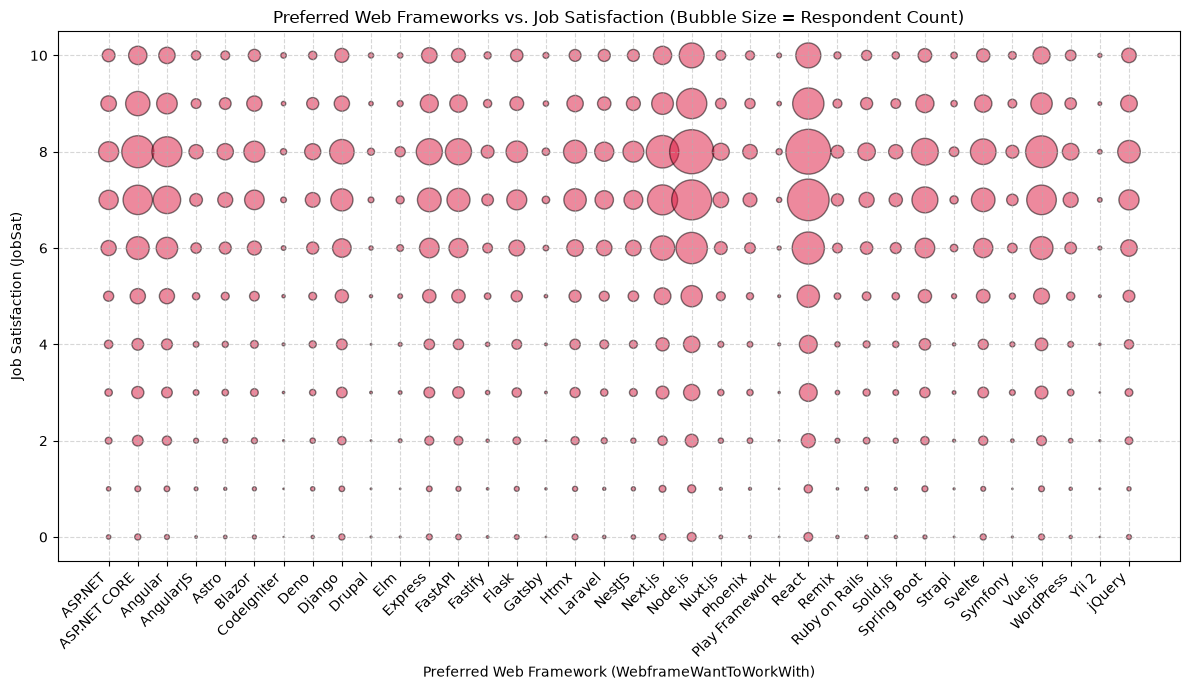

In [23]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean missing values and explode multi-value string column 'WebframeWantToWorkWith'
web_df = df[['WebframeWantToWorkWith', 'JobSat']].dropna().copy()

# Split semicolon-separated web frameworks into individual rows
web_df['Framework'] = web_df['WebframeWantToWorkWith'].str.split(';')
exploded_web = web_df.explode('Framework')

# 2. Group by Framework and JobSat to calculate respondent counts (bubble size)
grouped_web = (
    exploded_web.groupby(['Framework', 'JobSat'])
    .size()
    .reset_index(name='Count')
)

# 3. Create the bubble plot
plt.figure(figsize=(12, 7))

# Scale count for visible bubble size
bubble_size = grouped_web['Count'] * 0.5  # Adjust scaling factor if needed

plt.scatter(
    x=grouped_web['Framework'],
    y=grouped_web['JobSat'],
    s=bubble_size,
    alpha=0.5,
    c='crimson',
    edgecolors='black'
)

plt.xlabel('Preferred Web Framework (WebframeWantToWorkWith)')
plt.ylabel('Job Satisfaction (JobSat)')
plt.title('Preferred Web Frameworks vs. Job Satisfaction (Bubble Size = Respondent Count)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



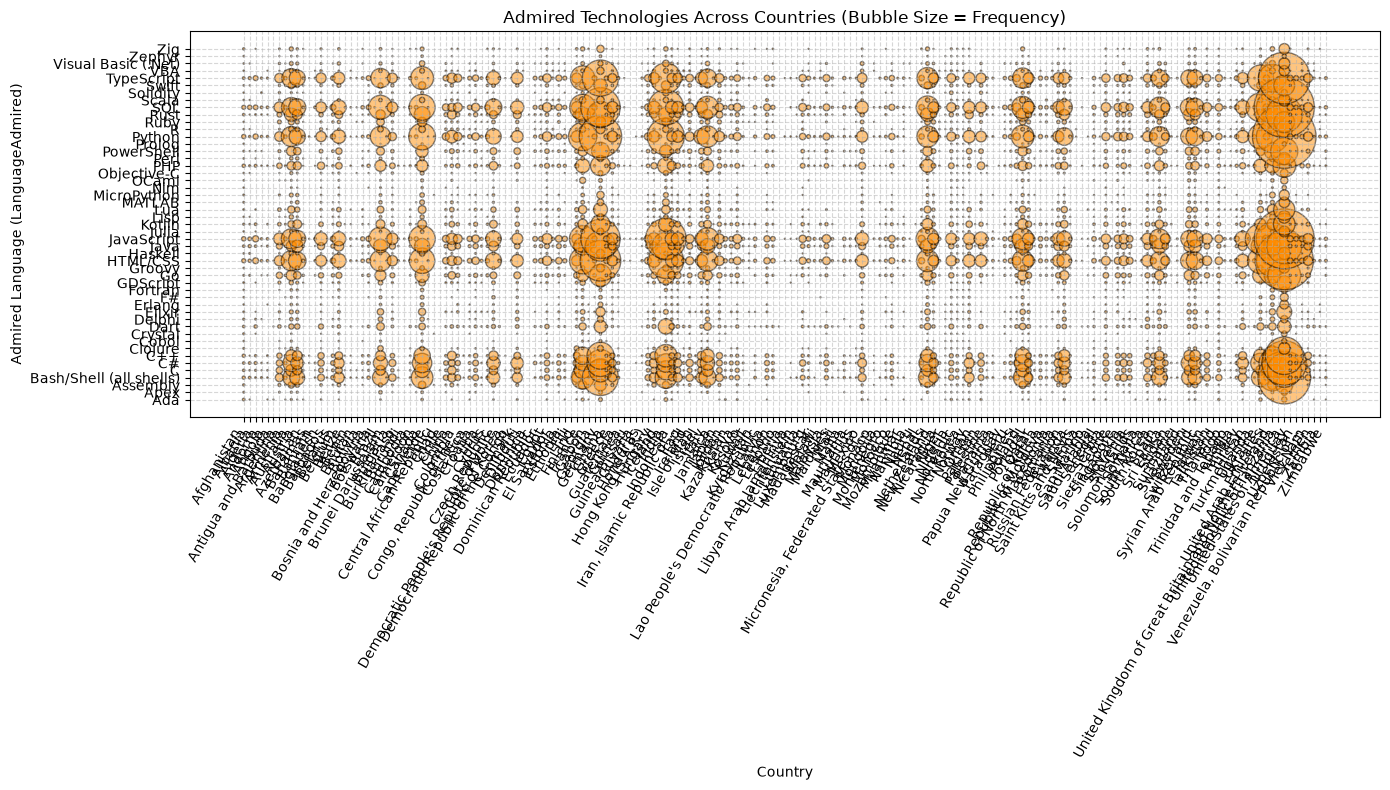

In [9]:
##Write your code here
import matplotlib.pyplot as plt
import pandas as pd

# 1. Clean missing values and explode multi-value string column 'LanguageAdmired'
tech_df = df[['Country', 'LanguageAdmired']].dropna().copy()

# Split semicolon-separated admired languages into individual rows
tech_df['Language'] = tech_df['LanguageAdmired'].str.split(';')
exploded_tech = tech_df.explode('Language')

# 2. Group by Country and Language to calculate frequency (count of respondents)
grouped_tech = (
    exploded_tech.groupby(['Country', 'Language'])
    .size()
    .reset_index(name='Frequency')
)

# 3. Create the bubble plot
plt.figure(figsize=(14, 8))

# Scale frequency for visible bubble size
bubble_size = grouped_tech['Frequency'] * 0.5  # Adjust scaling factor as needed

plt.scatter(
    x=grouped_tech['Country'],
    y=grouped_tech['Language'],
    s=bubble_size,
    alpha=0.5,
    c='darkorange',
    edgecolors='black'
)

plt.xlabel('Country')
plt.ylabel('Admired Language (LanguageAdmired)')
plt.title('Admired Technologies Across Countries (Bubble Size = Frequency)')
plt.xticks(rotation=60, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
